---------------------------------------------------------------------------------------------------------


# Exercise 2: Filtering and Extracting the Data
---------------------------------------------------------------------------------------------------------

In this exercise, you will prepare the titanic dataset for further processing in later units.

**Learning Outcomes**
1. be familiar with common data preparation procedures in pandas
2. visualise the data and get insight from your visualisation


To be able to follow this exercise you will need a csv file. This is the data for the passengers who boarded the famous Titanic ship (one and last) journey.

1- Either the file is assumed to be located within the 'data' directory within the same root directory of this page. 
2- Or it can be read/downloaded directly from https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv. 

The code is provided for both below (one is commented out)


In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading a CSV file

Let us see how we can load data from a file, particualrly from a csv file which is a very common comma separated set of data records :-). Its power lies within its simplicity. In pandas, reading a csv file is done using the read_csv() funciton.
We will load a titanic.csv file. 


In [13]:
titanic = pd.read_csv('datasets/titanic.csv') # use this if you want to retrieve a local copy of the titanic data
#titanic = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv') # use this to retrieve the titanic data online


To view the first five or n records of the titanic DataFrame we can use the head() function:

In [14]:
titanic.head(10)


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareAgeRatio,AgeRescaled,FareRescaled
0,597,598,0,3,"Johnson, Mr. Alfred",1,49.0,0,0,LINE,0.0000,NaN,S,0.000000,0.610455,0.000000
1,302,303,0,3,"Johnson, Mr. William Cahoone Jr",1,19.0,0,0,LINE,0.0000,NaN,S,0.000000,0.233476,0.000000
2,179,180,0,3,"Leonard, Mr. Lionel",1,36.0,0,0,LINE,0.0000,NaN,S,0.000000,0.447097,0.000000
3,806,807,0,1,"Andrews, Mr. Thomas Jr",1,39.0,0,0,112050,0.0000,A36,S,0.000000,0.484795,0.000000
4,271,272,1,3,"Tornquist, Mr. William Henry",1,25.0,0,0,LINE,0.0000,NaN,S,0.000000,0.308872,0.000000
5,263,264,0,1,"Harrison, Mr. William",1,40.0,0,0,112059,0.0000,B94,S,0.000000,0.497361,0.000000
6,822,823,0,1,"Reuchlin, Jonkheer. John George",1,38.0,0,0,19972,0.0000,NaN,S,0.000000,0.472229,0.000000
7,326,327,0,3,"Nysveen, Mr. Johan Hansen",1,61.0,0,0,345364,6.2375,NaN,S,0.102254,0.761247,0.012175
8,851,852,0,3,"Svensson, Mr. Johan",1,74.0,0,0,347060,7.7750,NaN,S,0.105068,0.924604,0.015176
9,116,117,0,3,"Connors, Mr. Patrick",1,70.5,0,0,370369,7.7500,NaN,Q,0.109929,0.880623,0.015127


Few words about the dataset: The SibSp represents the number of siblings and/or spouse that are on board with the passenger, while parch represents the number of parents and/or children that are on board with the passenger. Embarked is the port that the passenger embarked from to the ship. The most important field is 'Survived' which indicates whether a passenger has survived the trip or not. For a classification problem this is called the label.

## Selecting Fields

Let us see how we can select a specific subset of fields within this DataFrame. 
To do so we simply specify the fields names that we want to keep and leave out the fields that we do not want to include.
Note that the fields are shown in the above, however if you want to retrieve them programmatically then we can do so using print(titanic.columns).

In [15]:
print(titanic.columns)

Index(['Unnamed: 0', 'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
       'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FareAgeRatio',
       'AgeRescaled', 'FareRescaled'],
      dtype='object')


In [16]:
titanic_age_sex = titanic[['Age', 'Sex']]
titanic_age_sex.head()

,Age,Sex
0,49.0,1
1,19.0,1
2,36.0,1
3,39.0,1
4,25.0,1


On the other hand, if we wanted to filter out the 'age' and 'sex' fields then we can either state all columns except these two. Or it might be easier to use drop()

In [17]:
titanic_no_age_sex = titanic.drop(labels=['Age','Sex'],axis=1)
titanic_no_age_sex.head()


,Unnamed: 0,PassengerId,Survived,Pclass,Name,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareAgeRatio,AgeRescaled,FareRescaled
0,597,598,0,3,"Johnson, Mr. Alfred",0,0,LINE,0.0,NaN,S,0.0,0.610455,0.0
1,302,303,0,3,"Johnson, Mr. William Cahoone Jr",0,0,LINE,0.0,NaN,S,0.0,0.233476,0.0
2,179,180,0,3,"Leonard, Mr. Lionel",0,0,LINE,0.0,NaN,S,0.0,0.447097,0.0
3,806,807,0,1,"Andrews, Mr. Thomas Jr",0,0,112050,0.0,A36,S,0.0,0.484795,0.0
4,271,272,1,3,"Tornquist, Mr. William Henry",0,0,LINE,0.0,NaN,S,0.0,0.308872,0.0


In [18]:
titanic.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareAgeRatio,AgeRescaled,FareRescaled
0,597,598,0,3,"Johnson, Mr. Alfred",1,49.0,0,0,LINE,0.0,NaN,S,0.0,0.610455,0.0
1,302,303,0,3,"Johnson, Mr. William Cahoone Jr",1,19.0,0,0,LINE,0.0,NaN,S,0.0,0.233476,0.0
2,179,180,0,3,"Leonard, Mr. Lionel",1,36.0,0,0,LINE,0.0,NaN,S,0.0,0.447097,0.0
3,806,807,0,1,"Andrews, Mr. Thomas Jr",1,39.0,0,0,112050,0.0,A36,S,0.0,0.484795,0.0
4,271,272,1,3,"Tornquist, Mr. William Henry",1,25.0,0,0,LINE,0.0,NaN,S,0.0,0.308872,0.0


Note that pandas return a DataFrame type when we filter by a list of attributes, i.e. titanic[['Age','Sex']] returns a new DataFrame.

In [19]:
type(titanic_age_sex)

pandas.core.frame.DataFrame

## Selecting Records

Now let us obtain a subset of records (above we returned a subset of fields so we filtered vertically), below we filter horizontally, i.e. we obtain a smaller subsets of the available rows in the data frame.

In [20]:
titanic_adults = titanic['Age'] > 25
titanic_adults.head()

0     True
1    False
2     True
3     True
4    False
Name: Age, dtype: bool

Note that the operation titanic['Age'] > 25 returned a set of true/false values for each available record.
To utilise this filter we would need to pass this series of Boolean values to the titanic Data Frame again!

This is a common operation, we do the same also for numpy arrays, in fact a lot of the operations that we state here are available for numpy array and possibly motivated by that since pandas and numpy complement each other greatly. We provide a tutorial on numpy and data generation and data visualisation in another exercise.

In [21]:
titanic[titanic_adults].head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareAgeRatio,AgeRescaled,FareRescaled
0,597,598,0,3,"Johnson, Mr. Alfred",1,49.0,0,0,LINE,0.0,NaN,S,0.0,0.610455,0.0
2,179,180,0,3,"Leonard, Mr. Lionel",1,36.0,0,0,LINE,0.0,NaN,S,0.0,0.447097,0.0
3,806,807,0,1,"Andrews, Mr. Thomas Jr",1,39.0,0,0,112050,0.0,A36,S,0.0,0.484795,0.0
5,263,264,0,1,"Harrison, Mr. William",1,40.0,0,0,112059,0.0,B94,S,0.0,0.497361,0.0
6,822,823,0,1,"Reuchlin, Jonkheer. John George",1,38.0,0,0,19972,0.0,NaN,S,0.0,0.472229,0.0


Ok, let us check how many records we retrieved from the original titanic DataFrame

In [22]:
titanic.shape , titanic[titanic_adults].shape

((891, 16), (413, 16))

## GroupBy- one field

Let us see how we can group records by 'Sex' to see the average of males and females who boarded the ship.

In [23]:
titanic_byGender = titanic_age_sex.groupby(['Sex']).mean()
titanic_byGender.head()

,Age
Sex,
0,27.915709
1,30.726645


Note that the 'Age' attribute has the mean of all female and male ages on the ship and it shows that on average the females were 2.8 years younger than their males counterparts.

## GroupBy- multiple fields

In [24]:
titanic_byFare = titanic.drop(labels=['PassengerId','Name','Sex'],axis=1).groupby(['Age','Fare'],sort='descending').mean()
titanic_byFare.head(5)

Unnamed: 0  Survived  Pclass  SibSp  Parch  FareAgeRatio  \
Age  Fare                                                                
0.42 8.5167        803.0       1.0     3.0    0.0    1.0     20.277857   
0.67 14.5000       755.0       1.0     2.0    1.0    1.0     21.641791   
0.75 19.2583       556.5       1.0     3.0    2.0    1.0     25.677733   
0.83 18.7500       831.0       1.0     2.0    1.0    1.0     22.590361   
     29.0000        78.0       1.0     2.0    0.0    2.0     34.939759   

              AgeRescaled  FareRescaled  
Age  Fare                                
0.42 8.5167      0.000000      0.016623  
0.67 14.5000     0.003141      0.028302  
0.75 19.2583     0.004147      0.037590  
0.83 18.7500     0.005152      0.036598  
     29.0000     0.005152      0.056604

Ok, let us now filter first by 'Age' and 'Fare' and then we groupby and average via the 'Fare' attribute to see socioeconomic distribution of the journey.

In [26]:
titanic_byAgeFare = titanic[['Age','Fare']].groupby(['Fare'],sort='descending').mean()
titanic_byAgeFare.head(10)

,Age
Fare,
0.0000,35.142857
4.0125,20.000000
5.0000,33.000000
6.2375,61.000000
6.4375,34.500000
6.4500,43.000000
6.4958,26.000000
6.7500,18.500000
6.8583,NaN


Note how people around the age of 35 have not paid any fare and most likely been either crew or from a not well off class. Let us see how this has been distributed via the gender as well. Below, we do almost the same as above but we dissect the different operations.

In [27]:
titanic_byAgeFare = titanic[['Age','Fare', 'Sex']]
titanic_byAgeFare = titanic_byAgeFare.groupby(['Sex'],sort='ascending').mean()
titanic_byAgeFare.head(10)

,Age,Fare
Sex,,
0,27.915709,44.479818
1,30.726645,25.523893


The results show that females paid almost £19 more than their males counterparts in general (this is about £2000 in today's money) and on average were 2.8 years younger than their male counterpart.

## Calculating the Ratio of Two Fields

We can calculate a new field based on other fields in the dataset. This can be really useful sometimes when we want to pre-process the data before passing it to a modelling technique.

To show this, let us calculate the ratio of the 'Fare' and the 'Age' and assign the result to a new column (field) that we call 'FareAgeRatio' (although this might not make a lot of sense in the context of the Titanic dataset but it shows the concept)

In [28]:
titanic['FareAgeRatio'] = titanic['Fare']/titanic['Age'] 
titanic_ = titanic.sort_values(by=['FareAgeRatio'],inplace=True,ascending=True)
titanic.head(8)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareAgeRatio,AgeRescaled,FareRescaled
0,597,598,0,3,"Johnson, Mr. Alfred",1,49.0,0,0,LINE,0.0000,NaN,S,0.000000,0.610455,0.000000
1,302,303,0,3,"Johnson, Mr. William Cahoone Jr",1,19.0,0,0,LINE,0.0000,NaN,S,0.000000,0.233476,0.000000
2,179,180,0,3,"Leonard, Mr. Lionel",1,36.0,0,0,LINE,0.0000,NaN,S,0.000000,0.447097,0.000000
3,806,807,0,1,"Andrews, Mr. Thomas Jr",1,39.0,0,0,112050,0.0000,A36,S,0.000000,0.484795,0.000000
4,271,272,1,3,"Tornquist, Mr. William Henry",1,25.0,0,0,LINE,0.0000,NaN,S,0.000000,0.308872,0.000000
5,263,264,0,1,"Harrison, Mr. William",1,40.0,0,0,112059,0.0000,B94,S,0.000000,0.497361,0.000000
6,822,823,0,1,"Reuchlin, Jonkheer. John George",1,38.0,0,0,19972,0.0000,NaN,S,0.000000,0.472229,0.000000
7,326,327,0,3,"Nysveen, Mr. Johan Hansen",1,61.0,0,0,345364,6.2375,NaN,S,0.102254,0.761247,0.012175


## Summarising and Rescaling a Field

Sometimes it is useful to rescale the data in order to normalise it to make sure that all entries lie within the unit interval [0,1]. Such property has many benefits and it can guarantee better performance for some models such as the kNN (k Nearest Neigbours) technique discussed in unit 3. Effectively it prevents one attribute from dominating other attributes due to its values being large by nature in comparison to other attributes.

Let us see how we can do this in pandas succinctly for the age.
First let us see how we can get the max and min of the ages on our DataFrame

In [29]:
titanic.Age.max(), titanic.Age.min()


(80.0, 0.42)

To rescale we need to take each age, subtract it from the min and then we divide the result over the max - min

In [30]:
titanic['AgeRescaled'] = (titanic.Age - titanic.Age.min())/(titanic.Age.max()-titanic.Age.min())
titanic.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareAgeRatio,AgeRescaled,FareRescaled
0,597,598,0,3,"Johnson, Mr. Alfred",1,49.0,0,0,LINE,0.0,NaN,S,0.0,0.610455,0.0
1,302,303,0,3,"Johnson, Mr. William Cahoone Jr",1,19.0,0,0,LINE,0.0,NaN,S,0.0,0.233476,0.0
2,179,180,0,3,"Leonard, Mr. Lionel",1,36.0,0,0,LINE,0.0,NaN,S,0.0,0.447097,0.0
3,806,807,0,1,"Andrews, Mr. Thomas Jr",1,39.0,0,0,112050,0.0,A36,S,0.0,0.484795,0.0
4,271,272,1,3,"Tornquist, Mr. William Henry",1,25.0,0,0,LINE,0.0,NaN,S,0.0,0.308872,0.0


If we want to select the relevant attributes without creating a new DataFrame we can do so by creating a list of those relevant attributes. This is a better practice because trying to add a newly created attribute to a DataFrame copy will result in a warning. 

In [31]:
relevant = ['Survived', 'Pclass', 'Sex', 'Fare', 'Embarked', 'Age', 'AgeRescaled']
titanic[relevant].head()

,Survived,Pclass,Sex,Fare,Embarked,Age,AgeRescaled
0,0,3,1,0.0,S,49.0,0.610455
1,0,3,1,0.0,S,19.0,0.233476
2,0,3,1,0.0,S,36.0,0.447097
3,0,1,1,0.0,S,39.0,0.484795
4,1,3,1,0.0,S,25.0,0.308872


In [32]:
# we can create a smaller dataframe
relevant_small = ['Survived', 'Sex', 'Fare', 'Age', 'AgeRescaled']
titanic[relevant_small].head()

,Survived,Sex,Fare,Age,AgeRescaled
0,0,1,0.0,49.0,0.610455
1,0,1,0.0,19.0,0.233476
2,0,1,0.0,36.0,0.447097
3,0,1,0.0,39.0,0.484795
4,1,1,0.0,25.0,0.308872


Try to rescale the 'Fare' attribute

In [33]:
titanic['FareRescaled'] = (titanic.Fare - titanic.Fare.min())/(titanic.Fare.max()-titanic.Fare.min())

Let us see how the gender affected the survivals

In [34]:
titanic_byGender = titanic[['Sex','Survived','AgeRescaled','FareRescaled']].groupby(['Sex','Survived']).mean()
titanic_byGender.head()
#titanic_byGender.columns

AgeRescaled  FareRescaled
Sex Survived                           
0   0            0.309461      0.044941
    1            0.357222      0.101377
1   0            0.392034      0.042865
    1            0.337472      0.079678

---------------------------------------------------------------------------------------------------------


# Exercise 3 Plotting with Pandas


## Simple Command for Plotting in Pandas

There are some built-in capabilities to plot in pandas, however you might find it easier to use ‎matplotlib. Below we show both approaches.

,Age,Fare
Sex,,
0,27.915709,44.479818
1,30.726645,25.523893


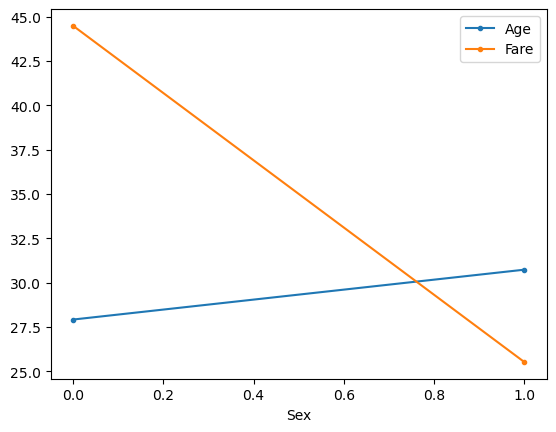

In [35]:
titanic_byAgeFare.plot(marker='.')
titanic_byAgeFare.head()

Note how the 'Fare' and 'Age' varies with gender

<AxesSubplot:xlabel='Fare', ylabel='Survived'>

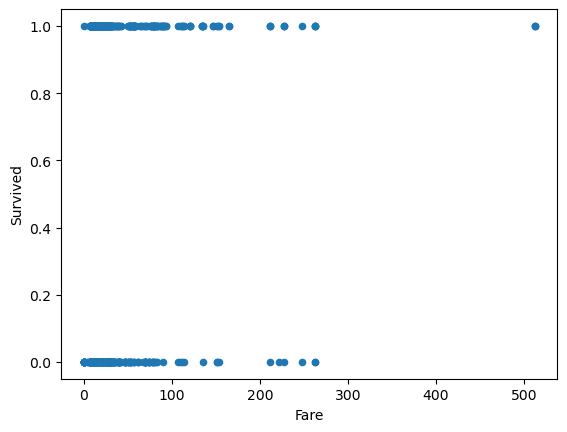

In [36]:
titanic.plot.scatter('Fare','Survived')

Note how survival seems not to be affected by the fair for the first £100 then the chances of survival are a bit higher for the [100,200] price bracket. Interestingly the [200, 300] seems to have similar chances and finally those who paid extremely high priced fare of more than £500 have survived.

<AxesSubplot:xlabel='Survived', ylabel='Fare'>

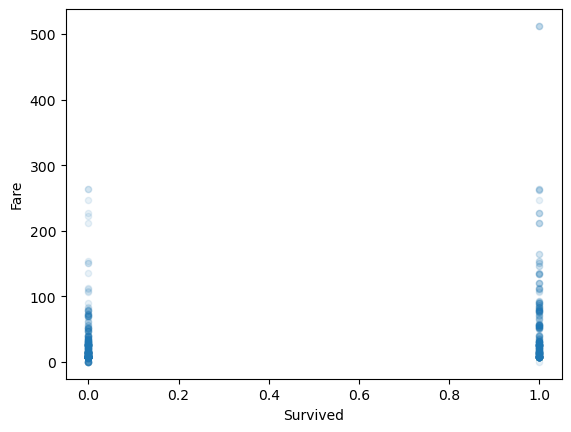

In [37]:
titanic.plot.scatter(x='Survived', y='Fare', alpha= 0.1)

The 'Fare' attribute seems to have no effect on the survival except for the very high fare values. The alpha argument is for how transparent the bubbles are, 1 is not transparent (the default) while 0 is completely transparent (which will not allow you to see anything so do not assign 0 to this parameter).

<AxesSubplot:xlabel='Survived', ylabel='Age'>

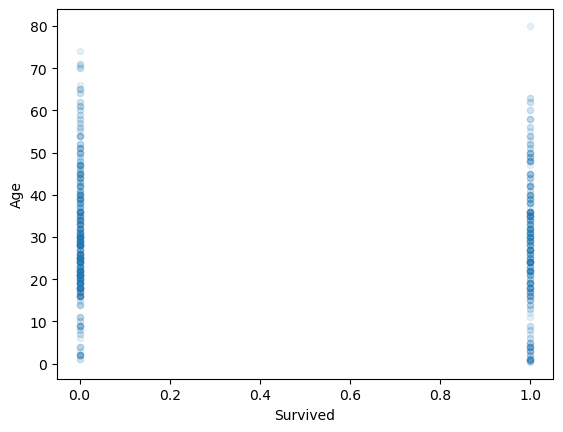

In [38]:
titanic.plot.scatter(x='Survived', y='Age', alpha=0.1)

This shows that the age group above 65 have less survival chances

## Converting Categorical into Numerical Data

If we would like to convert the gender values into 0 and 1 to be able to manipulate them, then this can be done as follows:

In [39]:
conversion_criteria = {"Sex":     {"female": 0, "male": 1}}
titanic = titanic.replace(conversion_criteria)
titanic["Sex"].value_counts()

1    577
0    314
Name: Sex, dtype: int64

## Data Visualisation from Different Perspectives

Let us now plot the Age against the Fare and see if there is some correlation with the survival of the passengers 

<AxesSubplot:xlabel='Age', ylabel='Fare'>

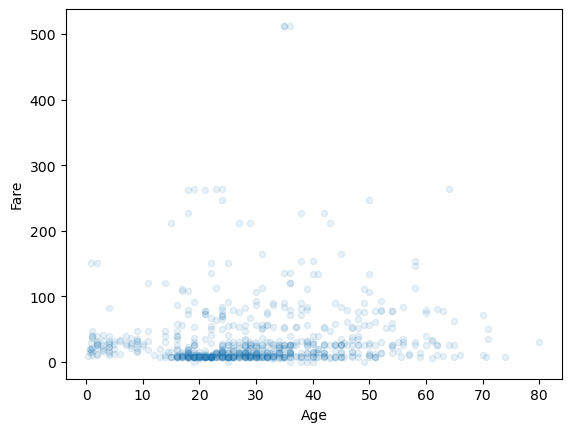

In [40]:
titanic.plot.scatter(x='Age', y='Fare', alpha=0.1)

Let us now plot the label of the data (Survived) against the gender. Note that this label can be used to predict the survival of a passenger in a supervised learning manner. You will learn more about this in the machine learning and data science modules.

<AxesSubplot:xlabel='Sex', ylabel='Survived'>

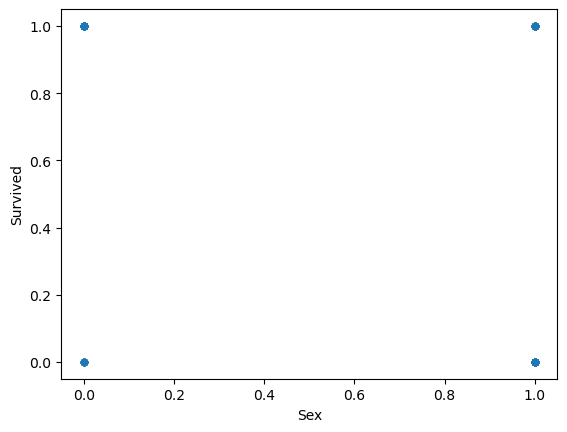

In [41]:
titanic.plot.scatter(x='Sex', y='Survived', alpha=0.1)

This seems to suggest that survival and non-survival occurred in all age and gender groups.

If we plot the gender against the survivals and the 'Fare' in a bubble plot, it becomes clearer that the Fare played a role in the survival of the passenger. At least we can say there is some correlation between them. Note that we have used the Fare to represent the size of each bubble. Note how it is possible to use the plt module (by importing the matplotlib.pyplot library) directly. Note that we have to use titanic DataFrame to refer to any attribute inside it, while we did not have to do that in the above examples, both ways are valid.

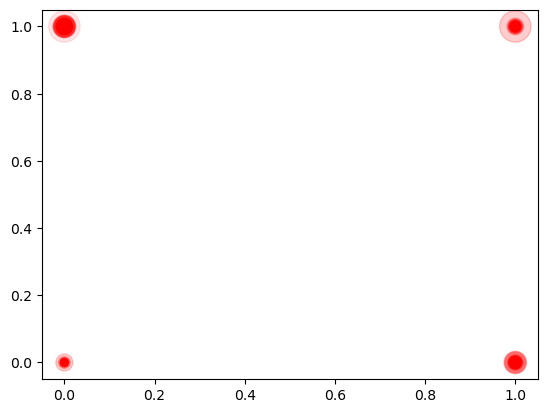

In [45]:
import matplotlib.pyplot as plt
plt.scatter(x=titanic['Sex'], y=titanic['Survived'], s = titanic['Fare'], alpha = 0.1, color = 'red')

Can you find a way to change the transparency and the colour the bubbles in the above example?
Can you find a way to plot the data in last section of Exercise 2?

Let us do the same for Age and Survived to see the effect of Age on survival chances

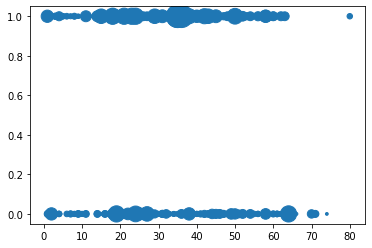

In [93]:
axs = plt.scatter(x=titanic['Age'], y=titanic['Survived'], s = titanic['Fare'])

The figure seems to suggest that people in their 30s had relatively better survival chances than people in their 20s, also people in their 60s had less chances of survival than everyone. Children above 10 years old had relatively better chances than younger age.

## Storing the results

Storing a dataframe as a csv file is the more efficient and convenient way.

In [94]:
# best is to do something like the below
titanic.to_csv('./titanic.csv')
